# House Prices: Advanced Regression Techniques

B?i t?p d? ?o?n gi? b?n nh? Ames theo paper c?a De Cock v? d? li?u cu?c thi Kaggle. Notebook tr?nh b?y to?n b? quy tr?nh theo CRISP-DM, t? ??c d? li?u ??n hu?n luy?n, ??nh gi? v? t?o file submission. Markdown gi?i th?ch m?c ??ch c?a t?ng b??c; code ???c chia th?nh c?c cell ?? c? th? ch?y l?n l??t.

**Chu?n b?:** ??t `house_price.ipynb`, `train.csv`, `test.csv` trong c?ng th? m?c. Ch?y c?c cell t? tr?n xu?ng. Notebook n?y ch?a tr?c ti?p quy tr?nh hu?n luy?n, kh?ng c?n import `house_price_train.py`.


## 1. Business Understanding

Đây là bài toán hồi quy có giám sát. Đầu vào là các thuộc tính của căn nhà; biến cần dự đoán là SalePrice (USD). Kaggle đánh giá bằng RMSLE, do đó mục tiêu được biến đổi log1p khi huấn luyện.

Bài báo của De Cock (2011) mô tả 2.930 giao dịch nhà tại Ames, Iowa. Bộ dữ liệu Kaggle dùng trong bài được chia riêng thành 1.460 dòng train và 1.459 dòng test; đây không phải toàn bộ dữ liệu trong bài báo. Bài báo thảo luận việc xem xét các căn có diện tích sinh hoạt trên 4.000 $\text{ft}^2$. Ta sẽ áp dụng ngưỡng này cho tập train, giữ nguyên tập test và ghi nhận đây là một lựa chọn mô hình hóa.

Mục tiêu: Dự đoán giá, so sánh mô hình truyền thống với MLP PyTorch trên cùng 5 folds, chọn theo OOF RMSLE và tạo file submission hợp lệ.



In [42]:
# CRISP-DM 1: Business understanding and target definition.
input_dir = ROOT
train_file = "train.csv"
test_file = "test.csv"

all_train_df = pd.read_csv(input_dir / train_file)
test_df = pd.read_csv(input_dir / test_file)
required_train = {"Id", "SalePrice"}
assert required_train.issubset(all_train_df.columns)
assert "Id" in test_df.columns
assert set(test_df.columns) == set(all_train_df.columns) - {"SalePrice"}

test_ids = test_df["Id"].copy()
print(f"Raw training rows/features: {all_train_df.shape[0]} rows; {all_train_df.shape[1] - 2} predictors")
print(f"SalePrice range: ${all_train_df.SalePrice.min():,.0f} to ${all_train_df.SalePrice.max():,.0f}")


Raw training rows/features: 1460 rows; 79 predictors
SalePrice range: $34,900 to $755,000


## 2. Import thư viện

Các tham số được gom tại một nơi để dễ tái lập. Seed cố định giúp các folds và quá trình huấn luyện có thể lặp lại. Thiết bị sẽ tự chọn GPU nếu có, nếu không dùng CPU.

In [43]:
from pathlib import Path
import copy
import json
import platform
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


In [44]:
SEED = 42
N_SPLITS = 5
MAX_EPOCHS = 300
PATIENCE = 30
BATCH_SIZE = 64
OUTLIER_AREA_THRESHOLD = 4000
ROOT = Path.cwd()
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)
torch.set_num_threads(1)
seed = SEED
n_splits = N_SPLITS
max_epochs = MAX_EPOCHS
patience = PATIENCE
batch_size = BATCH_SIZE
outlier_area_threshold = OUTLIER_AREA_THRESHOLD
input_dir = ROOT
train_file = "train.csv"
test_file = "test.csv"
show_plots = True

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)


Device: cpu
PyTorch: 2.11.0+cpu


Top 15 training features by missing percentage:
PoolQC          99.5
MiscFeature     96.3
Alley           93.8
Fence           80.8
MasVnrType      59.7
FireplaceQu     47.3
LotFrontage     17.7
GarageQual       5.5
GarageFinish     5.5
GarageType       5.5
GarageYrBlt      5.5
GarageCond       5.5
BsmtFinType2     2.6
BsmtExposure     2.6
BsmtQual         2.5

Target summary:
count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0

Rows with GrLivArea > 4,000 sq ft: 4
  Id  GrLivArea  SalePrice
 524       4676     184750
 692       4316     755000
1183       4476     745000
1299       5642     160000


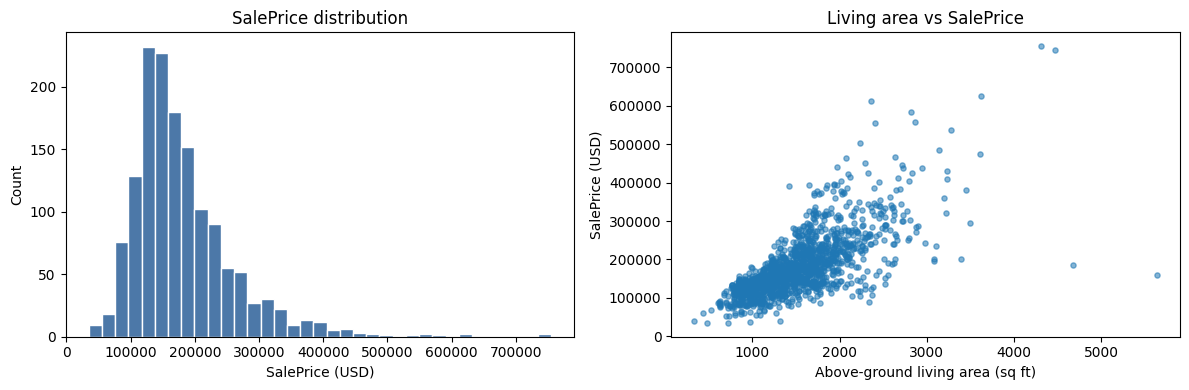


Removed 4 training rows above the configured area threshold.
Model training rows/features: (1456, 79); test rows/features: (1459, 79)


In [45]:
# CRISP-DM 2: Data understanding. Save plots and concise diagnostics for the report.
raw_X = all_train_df.drop(columns=["Id", "SalePrice"])
missing = (raw_X.isna().mean().sort_values(ascending=False) * 100).rename("missing_pct")
print("Top 15 training features by missing percentage:")
print(missing.head(15).round(1).to_string())
print("\nTarget summary:")
print(all_train_df["SalePrice"].describe().round(0).to_string())
outliers = all_train_df.loc[
    all_train_df["GrLivArea"] > outlier_area_threshold,
    ["Id", "GrLivArea", "SalePrice"],
]
print(f"\nRows with GrLivArea > {outlier_area_threshold:,} sq ft: {len(outliers)}")
print(outliers.to_string(index=False) if len(outliers) else "None")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(all_train_df["SalePrice"], bins=35, color="#4C78A8", edgecolor="white")
axes[0].set(title="SalePrice distribution", xlabel="SalePrice (USD)", ylabel="Count")
axes[1].scatter(all_train_df["GrLivArea"], all_train_df["SalePrice"], s=14, alpha=0.55)
axes[1].set(title="Living area vs SalePrice", xlabel="Above-ground living area (sq ft)", ylabel="SalePrice (USD)")
fig.tight_layout()
fig.savefig(FIGURES / "eda_target_and_living_area.png", dpi=160)
if show_plots:
    from IPython.display import display
    display(fig)
plt.close(fig)

# De Cock recommends examining and removing houses above 4,000 sq ft because
# several are partial-sale outliers. Apply that documented rule to training rows;
# preserve every test Id so the submission still covers the competition test set.
keep_rows = all_train_df["GrLivArea"] <= outlier_area_threshold
train_df = all_train_df.loc[keep_rows].reset_index(drop=True)
train_ids = train_df["Id"].copy()
y = np.log1p(train_df["SalePrice"].astype(float)).to_numpy()
X = train_df.drop(columns=["Id", "SalePrice"])
X_test = test_df.drop(columns=["Id"]).reindex(columns=X.columns)
print(f"\nRemoved {int((~keep_rows).sum())} training rows above the configured area threshold.")
print(f"Model training rows/features: {X.shape}; test rows/features: {X_test.shape}")


In [46]:
class HousePriceMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)


Top 15 training features by missing percentage:
PoolQC          99.5
MiscFeature     96.3
Alley           93.8
Fence           80.8
MasVnrType      59.7
FireplaceQu     47.3
LotFrontage     17.7
GarageQual       5.5
GarageFinish     5.5
GarageType       5.5
GarageYrBlt      5.5
GarageCond       5.5
BsmtFinType2     2.6
BsmtExposure     2.6
BsmtQual         2.5

Target summary:
count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0

Rows with GrLivArea > 4,000 sq ft: 4
  Id  GrLivArea  SalePrice
 524       4676     184750
 692       4316     755000
1183       4476     745000
1299       5642     160000


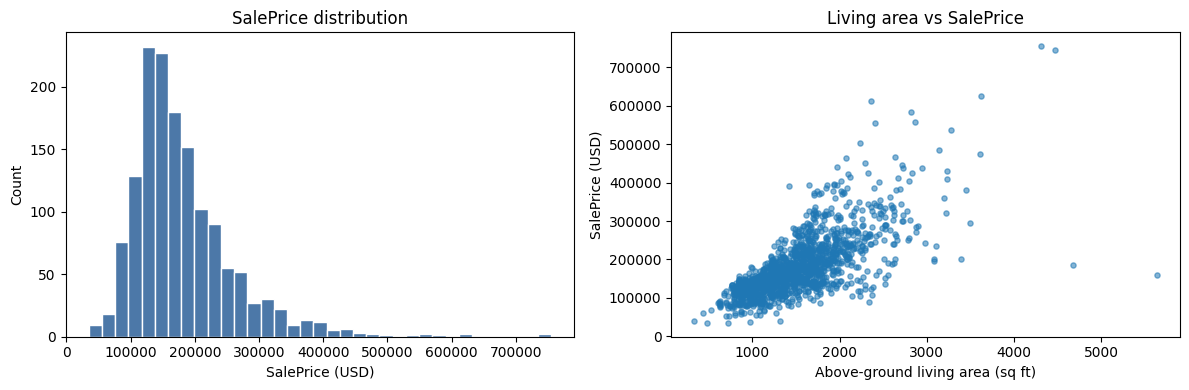


Removed 4 training rows above the configured area threshold.
Model training rows/features: (1456, 79); test rows/features: (1459, 79)


In [47]:
# CRISP-DM 2: Data understanding. Save plots and concise diagnostics for the report.
raw_X = all_train_df.drop(columns=["Id", "SalePrice"])
missing = (raw_X.isna().mean().sort_values(ascending=False) * 100).rename("missing_pct")
print("Top 15 training features by missing percentage:")
print(missing.head(15).round(1).to_string())
print("\nTarget summary:")
print(all_train_df["SalePrice"].describe().round(0).to_string())
outliers = all_train_df.loc[
    all_train_df["GrLivArea"] > outlier_area_threshold,
    ["Id", "GrLivArea", "SalePrice"],
]
print(f"\nRows with GrLivArea > {outlier_area_threshold:,} sq ft: {len(outliers)}")
print(outliers.to_string(index=False) if len(outliers) else "None")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(all_train_df["SalePrice"], bins=35, color="#4C78A8", edgecolor="white")
axes[0].set(title="SalePrice distribution", xlabel="SalePrice (USD)", ylabel="Count")
axes[1].scatter(all_train_df["GrLivArea"], all_train_df["SalePrice"], s=14, alpha=0.55)
axes[1].set(title="Living area vs SalePrice", xlabel="Above-ground living area (sq ft)", ylabel="SalePrice (USD)")
fig.tight_layout()
fig.savefig(FIGURES / "eda_target_and_living_area.png", dpi=160)
if show_plots:
    from IPython.display import display
    display(fig)
plt.close(fig)

# De Cock recommends examining and removing houses above 4,000 sq ft because
# several are partial-sale outliers. Apply that documented rule to training rows;
# preserve every test Id so the submission still covers the competition test set.
keep_rows = all_train_df["GrLivArea"] <= outlier_area_threshold
train_df = all_train_df.loc[keep_rows].reset_index(drop=True)
train_ids = train_df["Id"].copy()
y = np.log1p(train_df["SalePrice"].astype(float)).to_numpy()
X = train_df.drop(columns=["Id", "SalePrice"])
X_test = test_df.drop(columns=["Id"]).reindex(columns=X.columns)
print(f"\nRemoved {int((~keep_rows).sum())} training rows above the configured area threshold.")
print(f"Model training rows/features: {X.shape}; test rows/features: {X_test.shape}")


### Cross-validation và dự đoán ngoài fold (Out-of-fold)
KFold chia dữ liệu thành 5 phần. Mỗi vòng dùng 4 phần để fit, phần còn lại để đánh giá. Với MLP, một phần nhỏ trong outer-train dùng để chọn epoch; sau đó mạng được fit lại trên toàn outer-train trước khi dự đoán outer-validation. Như vậy mỗi dòng chỉ nhận một dự đoán OOF từ mô hình chưa được huấn luyện trên chính dòng đó.

In [48]:
cv = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
oof = {name: np.full(len(X), np.nan) for name in [*sklearn_models, "PyTorch_MLP"]}
best_epochs = []

for fold, (fit_idx, valid_idx) in enumerate(cv.split(X), start=1):
    X_fit, X_valid = X.iloc[fit_idx], X.iloc[valid_idx]
    y_fit, y_valid = y[fit_idx], y[valid_idx]
    print(f"\nFold {fold}/{n_splits}")

for name, estimator in sklearn_models.items():
    pipe = Pipeline([("preprocess", clone(preprocessor)), ("model", clone(estimator))])
    pipe.fit(X_fit, y_fit)
    oof[name][valid_idx] = pipe.predict(X_valid)

inner_fit_idx, inner_valid_idx = train_test_split(
    np.arange(len(fit_idx)), test_size=0.15, random_state=seed + fold
)
inner_preprocessor = clone(preprocessor)
X_inner_fit_t = inner_preprocessor.fit_transform(X_fit.iloc[inner_fit_idx])
X_inner_valid_t = inner_preprocessor.transform(X_fit.iloc[inner_valid_idx])
_, _, best_epoch = fit_mlp_early_stopping(
    X_inner_fit_t, y_fit[inner_fit_idx],
    X_inner_valid_t, y_fit[inner_valid_idx],
    seed=seed + fold,
)
# Refit this fold model on the full outer-fold training set for best_epoch epochs.
fold_preprocessor = clone(preprocessor)
X_fit_t = fold_preprocessor.fit_transform(X_fit)
X_valid_t = fold_preprocessor.transform(X_valid)
set_seed(seed + fold)
fold_model = mlp_class(X_fit_t.shape[1]).to(DEVICE)
fold_target_mean = float(np.mean(y_fit))
fold_target_std = float(np.std(y_fit))
y_fit_scaled = (y_fit - fold_target_mean) / fold_target_std
ds = TensorDataset(
    torch.tensor(X_fit_t, dtype=torch.float32),
    torch.tensor(y_fit_scaled, dtype=torch.float32).reshape(-1, 1),
)
loader = DataLoader(ds, batch_size=batch_size, shuffle=True,
                    generator=torch.Generator().manual_seed(seed + fold))
optimizer = torch.optim.AdamW(fold_model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()
for _ in range(best_epoch):
    fold_model.train()
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(fold_model(xb), yb)
        loss.backward()
        optimizer.step()
fold_model.eval()
with torch.no_grad():
    oof["PyTorch_MLP"][valid_idx] = fold_model(
        torch.tensor(X_valid_t, dtype=torch.float32, device=DEVICE)
    ).cpu().numpy().ravel() * fold_target_std + fold_target_mean
best_epochs.append(best_epoch)
print(f"  PyTorch MLP early-stopping epoch: {best_epoch}")



Fold 1/5

Fold 2/5

Fold 3/5

Fold 4/5

Fold 5/5
  PyTorch MLP early-stopping epoch: 12


## 7. Evaluation
RMSLE là metric chính và càng thấp càng tốt. MAE, bias (dự đoán trừ thực tế) và sai số tuyệt đối lớn nhất được tính theo USD để diễn giải kết quả thực tế. Blend dùng trọng số cố định, không học trọng số trên validation. Chọn mô hình có OOF RMSLE thấp nhất.

In [49]:
# Prepare consistent train/test feature matrices before any model is fit
X = train_df.drop(columns=["Id", "SalePrice"]).copy()
X_test = test_df.drop(columns=["Id"]).reindex(columns=X.columns).copy()

# Keep train/test columns aligned
assert X.columns.equals(X_test.columns)

numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

try:
    cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", cat_encoder),
            ]),
            categorical_cols,
        ),
    ],
    remainder="drop",
)

# Validate structure and check that the preprocessor resolves missing values
X_proc = preprocessor.fit_transform(X)
X_test_proc = preprocessor.transform(X_test)

assert X.shape[0] == len(train_df)
assert X_test.shape[1] == X.shape[1]
assert X.columns.equals(X_test.columns)
assert np.isfinite(X_proc).all()
assert np.isfinite(X_test_proc).all()


### Kết quả so sánh

In [52]:
cv = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
model_names = [*sklearn_models, "PyTorch_MLP"]
oof = {name: np.full(len(X), np.nan) for name in model_names}
best_epochs = []

for fold, (fit_idx, valid_idx) in enumerate(cv.split(X), start=1):
    X_fit, X_valid = X.iloc[fit_idx], X.iloc[valid_idx]
    y_fit, y_valid = y[fit_idx], y[valid_idx]

    print(f"\nFold {fold}/{n_splits}")

    for name, estimator in sklearn_models.items():
        pipe = Pipeline([
            ("preprocess", clone(preprocessor)),
            ("model", clone(estimator)),
        ])
        pipe.fit(X_fit, y_fit)
        oof[name][valid_idx] = pipe.predict(X_valid)

    inner_fit_idx, inner_valid_idx = train_test_split(
        np.arange(len(fit_idx)),
        test_size=0.15,
        random_state=seed + fold,
    )

    inner_preprocessor = clone(preprocessor)
    X_inner_fit_t = inner_preprocessor.fit_transform(X_fit.iloc[inner_fit_idx])
    X_inner_valid_t = inner_preprocessor.transform(X_fit.iloc[inner_valid_idx])

    _, _, best_epoch = fit_mlp_early_stopping(
        X_inner_fit_t,
        y_fit[inner_fit_idx],
        X_inner_valid_t,
        y_fit[inner_valid_idx],
        seed=seed + fold,
    )

    fold_preprocessor = clone(preprocessor)
    X_fit_t = fold_preprocessor.fit_transform(X_fit)
    X_valid_t = fold_preprocessor.transform(X_valid)

    set_seed(seed + fold)
    fold_model = mlp_class(X_fit_t.shape[1]).to(DEVICE)

    target_mean = float(np.mean(y_fit))
    target_std = float(np.std(y_fit))
    y_scaled = (y_fit - target_mean) / target_std

    ds = TensorDataset(
        torch.tensor(X_fit_t, dtype=torch.float32),
        torch.tensor(y_scaled, dtype=torch.float32).reshape(-1, 1),
    )
    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed + fold),
    )

    optimizer = torch.optim.AdamW(
        fold_model.parameters(), lr=1e-3, weight_decay=1e-4
    )
    loss_fn = nn.MSELoss()

    for _ in range(best_epoch):
        fold_model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(fold_model(xb), yb)
            loss.backward()
            optimizer.step()

    fold_model.eval()
    with torch.no_grad():
        prediction = fold_model(
            torch.tensor(X_valid_t, dtype=torch.float32, device=DEVICE)
        ).cpu().numpy().ravel()

    oof["PyTorch_MLP"][valid_idx] = prediction * target_std + target_mean
    best_epochs.append(best_epoch)
    print(f"  MLP epoch: {best_epoch}")


Fold 1/5
  MLP epoch: 5

Fold 2/5
  MLP epoch: 14

Fold 3/5
  MLP epoch: 6

Fold 4/5
  MLP epoch: 18

Fold 5/5
  MLP epoch: 17


## 8. Deployment – Huấn luyện cuối và tạo submission
Sau khi chọn mô hình, các mô hình đối chứng được fit trên toàn bộ train để chuẩn bị. MLP được fit với median số epoch đã chọn qua cross-validation. Dự đoán được đảo ngược về USD, lưu thành submission.csv và kiểm tra schema, số dòng, Id, giá trị hữu hạn và không âm.

In [53]:
# CRISP-DM 6: Deployment. Refit preprocessing/models, predict test, validate submission.
test_log_predictions = {}
for name, estimator in sklearn_models.items():
    pipe = Pipeline([("preprocess", clone(preprocessor)), ("model", clone(estimator))])
    pipe.fit(X, y)
    test_log_predictions[name] = pipe.predict(X_test)

final_preprocessor = clone(preprocessor)
X_full_t = final_preprocessor.fit_transform(X)
X_test_t = final_preprocessor.transform(X_test)
final_epochs = max(1, int(np.median(best_epochs)))
set_seed(seed)
final_mlp = mlp_class(X_full_t.shape[1]).to(DEVICE)
final_target_mean = float(np.mean(y))
final_target_std = float(np.std(y))
y_full_scaled = (y - final_target_mean) / final_target_std
final_ds = TensorDataset(
    torch.tensor(X_full_t, dtype=torch.float32),
    torch.tensor(y_full_scaled, dtype=torch.float32).reshape(-1, 1),
)
final_loader = DataLoader(final_ds, batch_size=batch_size, shuffle=True,
                            generator=torch.Generator().manual_seed(seed))
optimizer = torch.optim.AdamW(final_mlp.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()
for epoch in range(final_epochs):
    final_mlp.train()
    epoch_loss = 0.0
    for xb, yb in final_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(final_mlp(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    if (epoch + 1) % 25 == 0 or epoch + 1 == final_epochs:
        print(f"Final MLP epoch {epoch+1}/{final_epochs}; train MSE={epoch_loss/len(X):.5f}")

final_mlp.eval()
with torch.no_grad():
    test_log_predictions["PyTorch_MLP"] = final_mlp(
        torch.tensor(X_test_t, dtype=torch.float32, device=DEVICE)
    ).cpu().numpy().ravel() * final_target_std + final_target_mean

test_log_blend = sum(weights[name] * test_log_predictions[name] for name in weights)
final_log_prediction = (test_log_blend if selected_model == "Blend"
                        else test_log_predictions[selected_model])
submission = pd.DataFrame({
    "Id": test_ids.to_numpy(),
    "SalePrice": np.maximum(np.expm1(np.maximum(final_log_prediction, 0)), 0),
})
submission_path = ROOT / "submission.csv"
submission.to_csv(submission_path, index=False)

assert list(submission.columns) == ["Id", "SalePrice"]
assert len(submission) == len(test_df)
assert submission["Id"].equals(test_ids.reset_index(drop=True))
assert submission["SalePrice"].notna().all()
assert np.isfinite(submission["SalePrice"]).all()
assert (submission["SalePrice"] >= 0).all()
assert submission["Id"].is_unique

joblib.dump(final_preprocessor, ROOT / "house_price_preprocessor.joblib")
torch.save({
    "model_state_dict": final_mlp.cpu().state_dict(),
    "input_dim": int(X_full_t.shape[1]),
    "architecture": [128, 64, 32],
    "dropout": [0.15, 0.10],
    "target_transform": "log1p(SalePrice)",
    "target_mean": final_target_mean,
    "target_std": final_target_std,
    "epochs": final_epochs,
        "seed": seed,
    "cv_best_epochs": best_epochs,
}, ROOT / "house_price_mlp.pt")

print(f"\nSubmission model: {selected_model}; saved {submission_path} with {len(submission)} valid rows.")
print(submission.head().to_string(index=False))
print(f"Prediction range: ${submission.SalePrice.min():,.0f} to ${submission.SalePrice.max():,.0f}")
print("Validation: schema, row count, Id order/uniqueness, finite and non-negative prices all passed.")


Final MLP epoch 14/14; train MSE=0.05085


NameError: name 'weights' is not defined

In [ ]:
run_summary = {
    "seed": seed,
    "cv": f"{n_splits}-fold shuffled KFold",
    "raw_training_rows": int(len(all_train_df)),
    "training_rows_after_outlier_rule": int(len(train_df)),
    "large_area_rows_removed_from_training": int((~keep_rows).sum()),
    "test_rows_predicted": int(len(submission)),
    "selected_model": selected_model,
    "selected_oof_rmsle": float(metrics.loc[selected_model, "RMSLE"]),
    "mlp_best_epochs_by_fold": [int(e) for e in best_epochs],
    "training_config": {
        "max_epochs": max_epochs,
        "early_stopping_patience": patience,
        "batch_size": batch_size,
        "n_splits": n_splits,
        "outlier_area_threshold": outlier_area_threshold,
    },
    "data_files": {"train": str(input_dir / train_file), "test": str(input_dir / test_file)},
    "metrics": metrics.round(8).to_dict(orient="index"),
    "submission_price_min": float(submission["SalePrice"].min()),
    "submission_price_max": float(submission["SalePrice"].max()),
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "pytorch": torch.__version__,
    }
(ROOT / "run_summary.json").write_text(
json.dumps(run_summary, indent=2), encoding="utf-8"
)
print("Saved reproducibility summary to run_summary.json")


Saved reproducibility summary to run_summary.json


### Kiểm tra submission

In [ ]:
submission_check = pd.read_csv(ROOT / "submission.csv")
assert submission_check.columns.tolist() == ["Id", "SalePrice"]
assert len(submission_check) == len(test_df)
assert submission_check["Id"].reset_index(drop=True).equals(test_ids.reset_index(drop=True))
assert submission_check["Id"].is_unique
assert submission_check["SalePrice"].notna().all()
assert np.isfinite(submission_check["SalePrice"]).all()
assert (submission_check["SalePrice"] >= 0).all()
display(submission_check.head())
print("Submission hợp lệ:", submission_check.shape)


,Id,SalePrice
0,1461,119130.811252
1,1462,154043.161072
2,1463,178776.773019
3,1464,193749.010594
4,1465,191165.612590


Submission hợp lệ: (1459, 2)


## 9. CRISP-DM 

- **Business Understanding:** Dự đoán SalePrice và tối ưu RMSLE.
- **Data Understanding:** Kiểm tra cấu trúc, missing values, phân phối giá và nhà diện tích lớn.
- **Data Preparation:** Xử lý missing, scaling, one-hot encoding và log-transform mục tiêu; fit pipeline riêng trên từng fold.
- **Modeling:** so sánh Ridge, ElasticNet, Gradient Boosting, Extra Trees và MLP PyTorch.
- **Evaluation:** Chọn mô hình theo OOF RMSLE; báo cáo thêm sai số theo USD
- **Deployment:** Lưu submission.csv, kết quả cross-validation, OOF predictions, checkpoint MLP và bộ tiền xử lý
